# Fashion-MNIST CNN Model Comparison with and without Data Augmentation

This notebook demonstrates the training and evaluation of a Convolutional Neural Network (CNN) on the Fashion-MNIST dataset under two conditions:

1.  **Original Model (No Data Augmentation):** The CNN is trained directly on the raw Fashion-MNIST training images.
2.  **Augmented Model (With Data Augmentation):** The same CNN architecture is trained with an integrated data augmentation pipeline, applying random horizontal flips, random rotations, and random brightness adjustments to the training images.

The notebook covers data loading and preprocessing, model definition, training, evaluation, and a comparative analysis of the results, including generalization gaps, impact of augmentation, signs of overfitting, and changes in effective dataset size.

In [1]:
import tensorflow as tf
import numpy as np

# 1. Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Original training image shape:", x_train.shape)
print("Original training label shape:", y_train.shape)
print("Original testing image shape:", x_test.shape)
print("Original testing label shape:", y_test.shape)

# 2. Normalize the image data to range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("\nNormalized training image value range: ", x_train.min(), "-", x_train.max())
print("Normalized testing image value range: ", x_test.min(), "-", x_test.max())

# 3. Reshape the image data to include a channel dimension (grayscale has 1 channel)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

print("\nReshaped training image shape:", x_train.shape)
print("Reshaped testing image shape:", x_test.shape)

# 4. One-hot encode the labels (assuming CategoricalCrossentropy will be used)
num_classes = 10  # Fashion-MNIST has 10 classes
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print("\nOne-hot encoded training label shape:", y_train.shape)
print("One-hot encoded testing label shape:", y_test.shape)

print("Data loading and preprocessing complete.")

Original training image shape: (60000, 28, 28)
Original training label shape: (60000,)
Original testing image shape: (10000, 28, 28)
Original testing label shape: (10000,)

Normalized training image value range:  0.0 - 1.0
Normalized testing image value range:  0.0 - 1.0

Reshaped training image shape: (60000, 28, 28, 1)
Reshaped testing image shape: (10000, 28, 28, 1)

One-hot encoded training label shape: (60000, 10)
One-hot encoded testing label shape: (10000, 10)
Data loading and preprocessing complete.


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Create a Sequential model
model = Sequential([
    # 2. Add Conv2D layers with appropriate filters, kernel size, activation, and input_shape
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # 3. Add MaxPooling2D layers to reduce spatial dimensions
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    # 4. Add a Flatten layer to convert 2D feature maps into a 1D vector
    Flatten(),
    # 5. Add Dense layers for classification
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax') # num_classes is 10 from previous steps
])

# 6. Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 7. Print a summary of the model
print("CNN Model Architecture Summary:")
model.summary()

CNN Model Architecture Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

print("Model training complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 37ms/step - accuracy: 0.7722 - loss: 0.6250 - val_accuracy: 0.8759 - val_loss: 0.3460
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.8805 - loss: 0.3232 - val_accuracy: 0.8851 - val_loss: 0.3132
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 38ms/step - accuracy: 0.9009 - loss: 0.2704 - val_accuracy: 0.8975 - val_loss: 0.2824
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9144 - loss: 0.2287 - val_accuracy: 0.9017 - val_loss: 0.2736
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 35ms/step - accuracy: 0.9247 - loss: 0.2033 - val_accuracy: 0.9103 - val_loss: 0.2497
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9359 - loss: 0.1741 - val_accuracy: 0.9036 - val_loss: 0.2606
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.9424 - loss: 0.1545 - val_accuracy: 0.9126 - val_loss: 0.2527
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 36ms/step - accuracy: 0.9496 -

In [4]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomBrightness

# 1. Create a Sequential model for data augmentation
data_augmentation = Sequential([
    # 2. Add RandomFlip layer
    RandomFlip("horizontal"),
    # 3. Add RandomRotation layer
    RandomRotation(factor=0.1),
    # 4. Add RandomBrightness layer
    RandomBrightness(factor=0.2, value_range=(0.0, 1.0))
])

print("Data augmentation pipeline created successfully.")
print(data_augmentation.summary())

Data augmentation pipeline created successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Recreate the Sequential model with the same architecture
augmented_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax') # num_classes is 10
])

# 2. Compile the augmented_model
augmented_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Print a summary of the augmented model
print("Augmented CNN Model Architecture Summary:")
augmented_model.summary()

Augmented CNN Model Architecture Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Recreate the Sequential model with the same architecture, including the data augmentation layer
augmented_model = Sequential([
    data_augmentation, # Add the data augmentation pipeline as the first layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax') # num_classes is 10
])

# 2. Compile the augmented_model
augmented_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Print a summary of the augmented model
print("Augmented CNN Model Architecture Summary:")
augmented_model.summary()

Augmented CNN Model Architecture Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# 1. Recreate the Sequential model with the same architecture, including the data augmentation layer
augmented_model = Sequential([
    Input(shape=(28, 28, 1)), # Explicitly define the input shape for the model
    data_augmentation, # Add the data augmentation pipeline as the next layer
    Conv2D(32, (3, 3), activation='relu'), # Removed input_shape as it's now handled by the Input layer
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax') # num_classes is 10
])

# 2. Compile the augmented_model
augmented_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Print a summary of the augmented model
print("Augmented CNN Model Architecture Summary:")
augmented_model.summary()

Augmented CNN Model Architecture Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("Training the augmented model...")
augmented_history = augmented_model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

print("Augmented model training complete.")

Training the augmented model...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.6807 - loss: 0.8817 - val_accuracy: 0.8093 - val_loss: 0.5337
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.8183 - loss: 0.5055 - val_accuracy: 0.8435 - val_loss: 0.4447
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.8448 - loss: 0.4254 - val_accuracy: 0.8565 - val_loss: 0.4094
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.8592 - loss: 0.3876 - val_accuracy: 0.8597 - val_loss: 0.3974
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.8708 - loss: 0.3556 - val_accuracy: 0.8691 - val_loss: 0.3728
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - accuracy: 0.8750 - loss: 0.3438 - val_accuracy: 0.8541 - val_loss: 0.4139
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.8801 - loss: 0.3252 - val_accuracy: 0.8731 - val_loss: 0.3497
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81

In [9]:
print("Evaluating the original model...")
original_test_loss, original_test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Original Model Test Loss: {original_test_loss:.4f}")
print(f"Original Model Test Accuracy: {original_test_accuracy:.4f}")

Evaluating the original model...
Original Model Test Loss: 0.3087
Original Model Test Accuracy: 0.9092


In [10]:
print("Evaluating the augmented model...")
augmented_test_loss, augmented_test_accuracy = augmented_model.evaluate(x_test, y_test, verbose=0)

print(f"Augmented Model Test Loss: {augmented_test_loss:.4f}")
print(f"Augmented Model Test Accuracy: {augmented_test_accuracy:.4f}")

Evaluating the augmented model...
Augmented Model Test Loss: 0.3285
Augmented Model Test Accuracy: 0.8857


In [11]:
original_train_accuracy = history.history['accuracy'][-1]
original_val_accuracy = history.history['val_accuracy'][-1]

print(f"Original Model Training Accuracy: {original_train_accuracy:.4f}")
print(f"Original Model Validation Accuracy: {original_val_accuracy:.4f}")

Original Model Training Accuracy: 0.9596
Original Model Validation Accuracy: 0.9092


In [12]:
augmented_train_accuracy = augmented_history.history['accuracy'][-1]
augmented_val_accuracy = augmented_history.history['val_accuracy'][-1]

print(f"Augmented Model Training Accuracy: {augmented_train_accuracy:.4f}")
print(f"Augmented Model Validation Accuracy: {augmented_val_accuracy:.4f}")

Augmented Model Training Accuracy: 0.8880
Augmented Model Validation Accuracy: 0.8857


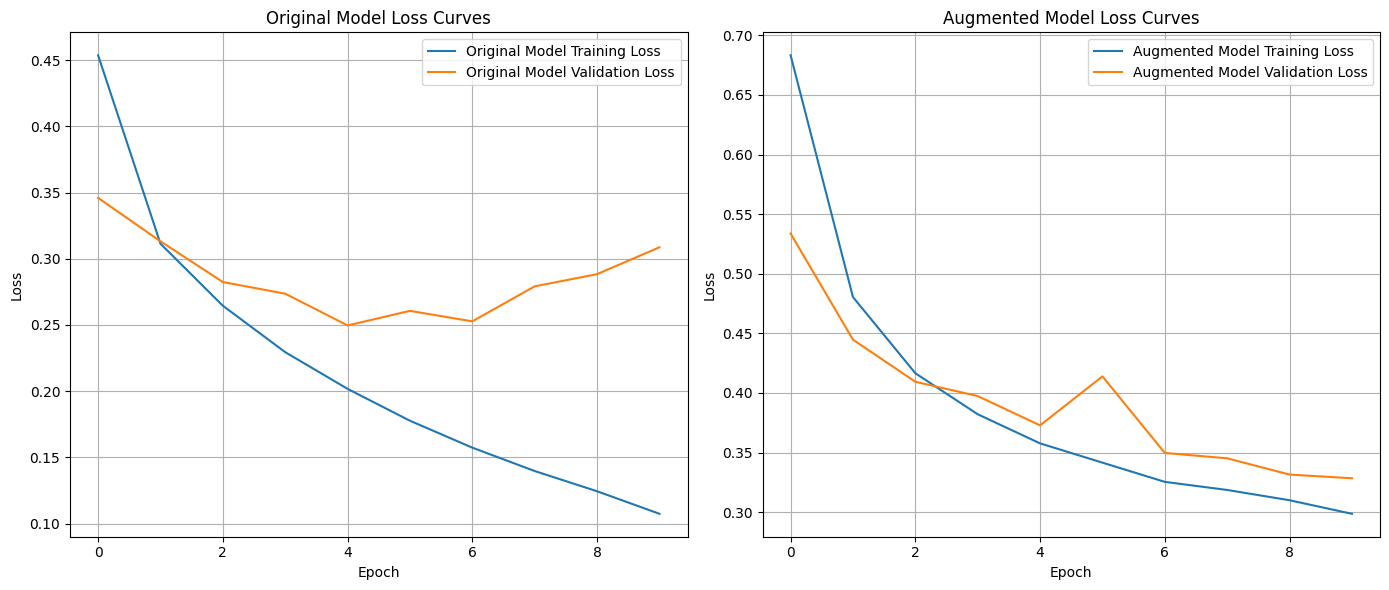

Loss curves plotted successfully.


In [13]:
import matplotlib.pyplot as plt

# 1. Create a figure with two subplots
plt.figure(figsize=(14, 6))

# Subplot for Original Model Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Original Model Training Loss')
plt.plot(history.history['val_loss'], label='Original Model Validation Loss')
plt.title('Original Model Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot for Augmented Model Loss
plt.subplot(1, 2, 2)
plt.plot(augmented_history.history['loss'], label='Augmented Model Training Loss')
plt.plot(augmented_history.history['val_loss'], label='Augmented Model Validation Loss')
plt.title('Augmented Model Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Display the plot
plt.tight_layout()
plt.show()

print("Loss curves plotted successfully.")